In [120]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error
import numpy as np
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import shapiro
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, make_scorer,r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor



In [121]:
df_train = pd.read_csv("train_df.csv")
df_test = pd.read_csv("test_df.csv")

In [122]:
df = pd.read_csv("salaries_cleaned.csv")

# Prepping data for modelling

Making it from a numeric variable to a qualitative variable for Encoding purpose (Does not make a difference just easier for interpretation)

In [123]:
def map_remote_ratio(df:pd.DataFrame): 
    df["remote_ratio"] = df["remote_ratio"].map({
        0: "No",
        50: "Partially",
        100: "Fully"
    })
    
map_remote_ratio(df_train)
map_remote_ratio(df_test)
map_remote_ratio(df)


In [124]:
X = df.copy().drop("salary_in_usd",axis=1)
y = df.copy()["salary_in_usd"]

In [125]:
X_train = df_train.copy().drop("salary_in_usd",axis=1)
y_train = df_train.copy()["salary_in_usd"]

X_test = df_test.copy().drop("salary_in_usd",axis=1)
y_test = df_test.copy()["salary_in_usd"]

## Encoding

One-Hot encoding on the Employment type and remote ration given they are nominal variables and cardinality is somewhat small

In [126]:
# Columns to encode
ohe_cols = ["employment_type", "remote_ratio"]

# 1. Fit encoder on the FULL dataset
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop='first')
ohe.fit(X[ohe_cols])   # Fit on all data

# 2. Transform TRAIN and TEST sets separately
X_train_encoded = ohe.transform(X_train[ohe_cols])
X_test_encoded  = ohe.transform(X_test[ohe_cols])

# 3. Convert to DataFrames
train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=ohe.get_feature_names_out(ohe_cols),
    index=X_train.index
)

test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=ohe.get_feature_names_out(ohe_cols),
    index=X_test.index
)

# 4. Drop original categorical columns
X_train = X_train.drop(columns=ohe_cols)
X_test  = X_test.drop(columns=ohe_cols)

# 5. Join encoded columns
X_train = X_train.join(train_encoded_df)
X_test  = X_test.join(test_encoded_df)

Ordinal encoding

In [127]:
# Ordinal encode experience_level
experience_map = {
    "EN": 0,
    "MI": 1,
    "SE": 2,
    "EX": 3
}

# Ordinal encode company_size
company_size_map = {
    "S": 0,
    "M": 1,
    "L": 2
}

X_train["experience_level"] = X_train["experience_level"].map(experience_map)
X_train["company_size"] = X_train["company_size"].map(company_size_map)

X_test["experience_level"] = X_test["experience_level"].map(experience_map)
X_test["company_size"] = X_test["company_size"].map(company_size_map)


## Target encoding

Target encoding on the "employee_residence", "company_location","job_title" that are nominal variable however One-hot encodinf does not fit this given the high cardinality of the variable. 

In [128]:
target_enc = TargetEncoder(
    cols=["employee_residence", "company_location","job_title"], 
    smoothing=0.25
)

X_train = target_enc.fit_transform(X_train, y_train)
X_test = target_enc.transform(X_test)

# Initial model fitting

In [129]:
model = LinearRegression()

pipe = make_pipeline(
    model    
)

In [130]:
mlr = pipe.fit(X_train,y_train)

In [131]:
mlr.score(X_train,y_train)

0.26746683178966935

In [132]:
mlr.score(X_test,y_test)

0.26763307440520423

In [133]:
X_ols = sm.add_constant(X_train) 
ols = sm.OLS(y_train, X_ols).fit()

In [134]:
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:          salary_in_usd   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.267
Method:                 Least Squares   F-statistic:                     1391.
Date:                Thu, 20 Nov 2025   Prob (F-statistic):               0.00
Time:                        11:06:45   Log-Likelihood:            -5.2514e+05
No. Observations:               41929   AIC:                         1.050e+06
Df Residuals:                   41917   BIC:                         1.050e+06
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                  -4.13

## Feature Selection

#### Forward selection

In [135]:
lr = LinearRegression()
forward_selection = SequentialFeatureSelector(
    lr,
    direction="forward",
    scoring="neg_mean_squared_error",
    cv=10,
    n_features_to_select="auto",  # automatically chooses best subset
    n_jobs=-1
)

In [136]:
forward_selection.fit(X_train, y_train)

selected_features = X_train.columns[forward_selection.get_support()]
print("Selected features:", selected_features)

Selected features: Index(['experience_level', 'job_title', 'employee_residence',
       'employment_type_FT', 'remote_ratio_No'],
      dtype='object')


In [137]:
X_train = X_train[selected_features]
X_test = X_test[selected_features]

In [138]:
mlr = pipe.fit(X_train,y_train)

In [139]:
mlr.score(X_train,y_train)

0.2666667845557943

### Baseline model

In [140]:
# Fitting a log transformed Y variable 
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

X_ols = sm.add_constant(X_train) 
ols = sm.OLS(y_train_log, X_ols).fit()

In [141]:
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:          salary_in_usd   R-squared:                       0.379
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     5115.
Date:                Thu, 20 Nov 2025   Prob (F-statistic):               0.00
Time:                        11:06:48   Log-Likelihood:                -22414.
No. Observations:               41929   AIC:                         4.484e+04
Df Residuals:                   41923   BIC:                         4.489e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  9.0659      0

In [142]:
residuals = ols.resid
fitted_vals = ols.fittedvalues

Linearity and homoscedasticity

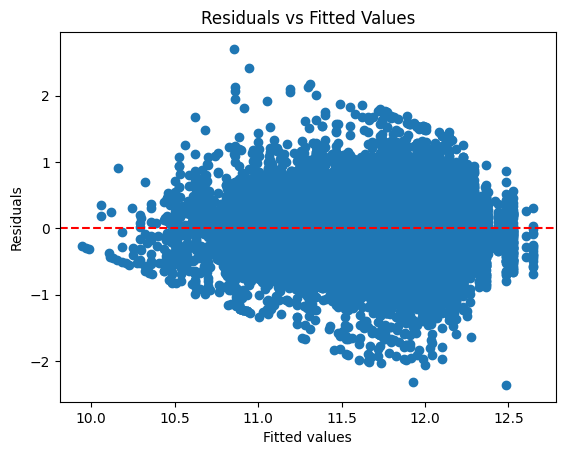

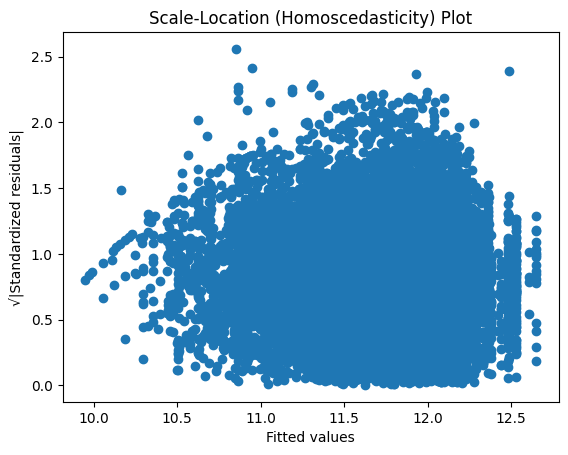

In [143]:
plt.scatter(fitted_vals, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.show()

# Scale-location plot for homoscedasticity
std_resid = residuals / residuals.std()
plt.scatter(fitted_vals, (abs(std_resid))**0.5)
plt.title('Scale-Location (Homoscedasticity) Plot')
plt.xlabel('Fitted values')
plt.ylabel('√|Standardized residuals|')
plt.show()

Independence of errors

Normality of residuals

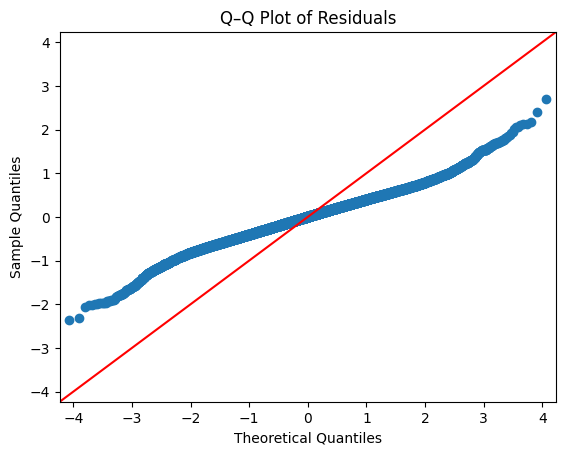

Shapiro–Wilk statistic: 0.994, p-value: 0.000


/Users/user/Desktop/ada/2nd year/2nd semester/Machine learning/Assignment/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 41929.
  res = hypotest_fun_out(*samples, **kwds)


In [144]:
qqplot(residuals, line='45')
plt.title('Q–Q Plot of Residuals')
plt.show()

stat, p_value = shapiro(residuals)
print(f'Shapiro–Wilk statistic: {stat:.3f}, p-value: {p_value:.3f}')

Multicollinearility

In [145]:
vif = pd.DataFrame()
vif["feature"] = X_train.columns
vif["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print(vif)

              feature        VIF
0    experience_level   5.391883
1           job_title  24.828106
2  employee_residence  38.699433
3  employment_type_FT  46.288936
4     remote_ratio_No   3.954059


outliers

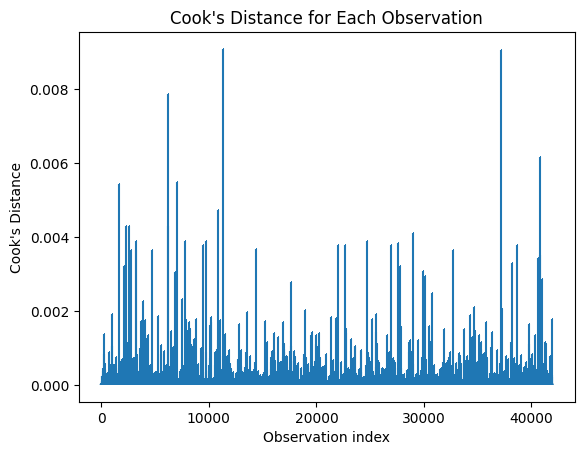

Potentially influential observations: [   39    42    92 ... 41878 41905 41913]


In [146]:
influence = ols.get_influence()
cooks_d = influence.cooks_distance[0]

# Cook's distance stem plot without deprecated argument
plt.stem(
    np.arange(len(cooks_d)),  # indices
    cooks_d,                  # Cook's distance values
    linefmt='-',              # line style (optional)
    markerfmt=',',            # marker style (optional)
    basefmt=' '               # base line style (optional)
)
plt.title("Cook's Distance for Each Observation")
plt.xlabel('Observation index')
plt.ylabel("Cook's Distance")
plt.show()

# Flag observations with Cook’s distance > 4/n
n = len(y)
influential_points = np.where(cooks_d > 4/n)[0]
print(f'Potentially influential observations: {influential_points}')

In [147]:
len(influential_points)

2540

Tweaking the Linearity and constant variance problem

In [148]:
# Use 5‑fold CV with shuffling
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Negative scoring so that cross_val_score returns positive errors after negation
rmse_scorer = make_scorer(lambda y_true, y_pred: 
                          np.sqrt(mean_squared_error(y_true, y_pred)),
                          greater_is_better=False)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

In [149]:
# Base pipelines for OLS, Ridge and Lasso
pipelines = {
    'OLS': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge': Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'Lasso': Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.001))]),
}

In [150]:
from sklearn.base import BaseEstimator, RegressorMixin

class WeightedLeastSquares(BaseEstimator, RegressorMixin):
    def fit(self, X, y):
        X_const = sm.add_constant(X)
        # Fit OLS to get residuals
        ols = sm.OLS(y, X_const).fit()
        residuals = y - ols.predict(X_const)
        # Weights: inverse of squared residuals (add a small constant to avoid division by zero)
        weights = 1.0 / (residuals**2 + 1e-8)
        # Fit WLS with these weights
        self.wls = sm.WLS(y, X_const, weights=weights).fit()
        return self

    def predict(self, X):
        X_const = sm.add_constant(X)
        return self.wls.predict(X_const)

In [151]:
pipelines['WLS'] = WeightedLeastSquares()

In [152]:
results = []

def rmse_original(y_true, y_pred_log):
    y_pred = np.exp(y_pred_log)               # convert back to salary
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae_original(y_true, y_pred_log):
    y_pred = np.exp(y_pred_log)
    return mean_absolute_error(y_true, y_pred)

rmse_original_scorer = make_scorer(rmse_original, greater_is_better=False)
mae_original_scorer  = make_scorer(mae_original,  greater_is_better=False)



for name, model in pipelines.items():
    rmse_scores = -cross_val_score(model, X_train, y_train_log,
                                   cv=kfold,
                                   scoring=rmse_original_scorer)

    mae_scores  = -cross_val_score(model, X_train, y_train_log,
                                   cv=kfold,
                                   scoring=mae_original_scorer)

    results.append({
        'Model': name,
        'RMSE mean': rmse_scores.mean(),
        'RMSE std':  rmse_scores.std(),
        'MAE mean':  mae_scores.mean(),
        'MAE std':   mae_scores.std()
    })

results_df = pd.DataFrame(results).sort_values('RMSE mean')
print(results_df)

   Model      RMSE mean    RMSE std       MAE mean     MAE std
2  Lasso  145061.019175  294.865131  139689.342683  297.879514
1  Ridge  145174.605308  294.516598  139752.235835  297.752969
0    OLS  145175.120849  294.524074  139752.521376  297.760908
3    WLS  145177.556736  294.346011  139755.621058  298.124369


It can be seen the other models does not have a particular higher performance gain over OLS therefore it can be said that OLS is on par with other alternatives

In [153]:
pipelines["OLS"].fit(X_train, y_train_log)

pred_test_log = pipelines["OLS"].predict(X_test)
pred_test = np.exp(pred_test_log)

r2_original = r2_score(y_test, pred_test)
print("R² (original scale):", r2_original)

mean_absolute_error(y_test, pred_test)

R² (original scale): 0.2509154621892593


47030.89612880658

## FinalPipeline

In [154]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LinearRegression

from category_encoders import TargetEncoder

X_train = df_train.copy().drop("salary_in_usd",axis=1)
y_train = df_train.copy()["salary_in_usd"]

X_test = df_test.copy().drop("salary_in_usd",axis=1)
y_test = df_test.copy()["salary_in_usd"]


def map_remote_ratio_df(X):
    X = X.copy()
    mapping = {0: "No", 50: "Partially", 100: "Fully"}
    X["remote_ratio"] = X["remote_ratio"].map(mapping)
    return X

remote_mapper = FunctionTransformer(map_remote_ratio_df, feature_names_out="one-to-one")

# 1) One-hot
ohe_cols = ["employment_type", "remote_ratio"]

# 2) Ordinal
ordinal_cols = ["experience_level", "company_size"]
ordinal_categories = [
    ["EN", "MI", "SE", "EX"],  # experience_level
    ["S", "M", "L"],           # company_size
]

# 3) Target encoded
target_cols = ["employee_residence", "company_location", "job_title"]

# 4) Numeric (pass through + optionally scale)
numeric_cols = ["work_year"]   # add more numeric features if you have them

preprocessor = ColumnTransformer(
    transformers=[
        ("ohe",
         OneHotEncoder(drop="first", handle_unknown="ignore"),
         ohe_cols),
        
        ("ord",
         OrdinalEncoder(categories=ordinal_categories),
         ordinal_cols),
        
        ("target",
         TargetEncoder(cols=target_cols, smoothing=0.25),
         target_cols),
        
        ("num",
         StandardScaler(),   # or "passthrough" if you don't want scaling
         numeric_cols),
    ],
    remainder="drop"  # drop any columns not listed above
)

feature_selector = SequentialFeatureSelector(
    estimator=LinearRegression(),
    direction="forward",                 # or "backward"
    n_features_to_select="auto",         # or an int if you want a fixed size
    scoring="neg_mean_squared_error",    # or "neg_root_mean_squared_error"
    cv=5,
    n_jobs=-1
)

# Base model (X side only)
x_pipeline = Pipeline(steps=[
    ("remote_map", remote_mapper),   # maps remote_ratio 0/50/100 -> text
    ("preprocess", preprocessor), # encoders & scaler
    ("select", feature_selector),
    ("model", LinearRegression())
    
])
log_linreg = TransformedTargetRegressor(
    regressor=x_pipeline,
    func=np.log,      # y -> log(y) during fit
    inverse_func=np.exp  # prediction back to original scale
)


In [155]:
log_linreg.fit(X_train, y_train)


,regressor,Pipeline(step...egression())])
,transformer,None
,func,<ufunc 'log'>
,inverse_func,<ufunc 'exp'>
,check_inverse,True
,func,<function map...t 0x1612d89a0>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,'one-to-one'


In [156]:
# Split X, y from the *raw* df (with original columns)
X = df.drop(columns=["salary_in_usd"])
y = df["salary_in_usd"]

# Train/test you already have:
X_train = df_train.drop(columns=["salary_in_usd"])
y_train = df_train["salary_in_usd"]

X_test = df_test.drop(columns=["salary_in_usd"])
y_test = df_test["salary_in_usd"]

# Fit
log_linreg.fit(X_train, y_train)

# Predict on test (back on salary_in_usd scale)
y_pred_test = log_linreg.predict(X_test)


r2  = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae  = mean_absolute_error(y_test, y_pred_test)

print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R²: 0.24618020602855195
RMSE: 67902.80029144358
MAE: 46954.47167131408
